# Clustering con DBSCAN – Dataset Wine
**Actividad Parte 1 (2D) y Parte 2 (3D)**

Se aplica DBSCAN al dataset Wine de scikit-learn, se prueban múltiples combinaciones de hiperparámetros, se compara con KMeans y se evalúa con la métrica DBCV.

## 0. Importaciones y carga de datos

In [ ]:
import numpy as np                          # Operaciones numéricas con arrays
import pandas as pd                         # Manejo de datos en estructura tabular
import matplotlib.pyplot as plt             # Visualización de gráficas
from mpl_toolkits.mplot3d import Axes3D     # Soporte para gráficas 3D en matplotlib

from sklearn.datasets import load_wine              # Dataset Wine incluido en scikit-learn
from sklearn.preprocessing import StandardScaler    # Estandarización de variables (media 0, desv 1)
from sklearn.cluster import DBSCAN                  # Algoritmo de clustering DBSCAN
from sklearn.cluster import KMeans                  # Algoritmo de clustering KMeans
from sklearn.metrics import silhouette_score        # Métrica de evaluación de clustering

from hdbscan.validity import validity_index         # Métrica DBCV para clustering basado en densidad

import warnings
warnings.filterwarnings('ignore')           # Suprime advertencias para mayor limpieza en la salida

In [ ]:
wine = load_wine()                          # Carga el dataset Wine (178 muestras, 13 características)

df = pd.DataFrame(                          # Convierte los datos a DataFrame para inspección sencilla
    wine.data,
    columns=wine.feature_names
)

print("Shape del dataset completo:", df.shape)   # Muestra filas y columnas del dataset
print("\nPrimeras filas:")
df.head()                                   # Imprime las primeras 5 filas del DataFrame

Shape del dataset completo: (178, 13)

Primeras filas:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


---
## PARTE 1 – DBSCAN en 2D
Se seleccionan las dos primeras características del dataset para poder graficar en un plano 2D.

### 1.1 Preparación de datos 2D

In [ ]:
X2 = wine.data[:, :2]                       # Selecciona las 2 primeras variables para graficar en 2D
feat2 = wine.feature_names[:2]              # Guarda los nombres de esas 2 columnas

scaler2 = StandardScaler()                  # Crea el objeto estandarizador para 2D
X2_scaled = scaler2.fit_transform(X2)       # Ajusta y transforma: resta media y divide entre desviación estándar

print("Variables 2D usadas:", feat2)        # Confirma qué variables se van a usar
print("Shape datos 2D:", X2_scaled.shape)   # Verifica dimensiones del subconjunto

Variables 2D usadas: ['alcohol', 'malic_acid']
Shape datos 2D: (178, 2)


### 1.2 Búsqueda de hiperparámetros DBSCAN (2D)
Se prueban múltiples combinaciones de `eps` (radio de vecindad) y `min_samples` (puntos mínimos para formar un núcleo).

In [ ]:
eps_values    = [0.3, 0.5, 0.8, 1.0, 1.5]  # Lista de radios de vecindad a probar
min_samples_values = [3, 5, 8, 10]          # Lista de mínimos de puntos por núcleo a probar

results_2d = []                             # Lista vacía donde se guardarán los resultados

for eps in eps_values:                      # Itera sobre cada valor de eps
    for ms in min_samples_values:           # Itera sobre cada valor de min_samples
        db = DBSCAN(eps=eps, min_samples=ms)        # Instancia DBSCAN con los hiperparámetros actuales
        labels = db.fit_predict(X2_scaled)          # Ajusta y predice etiquetas de cluster (-1 = ruido)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # Cuenta clusters ignorando ruido
        n_noise    = np.sum(labels == -1)           # Cuenta puntos clasificados como ruido

        # Calcula DBCV solo si hay al menos 2 clusters y no todos son ruido
        if n_clusters >= 2 and n_noise < len(labels):
            try:
                dbcv = validity_index(              # Calcula la métrica DBCV (Density-Based Clustering Validation)
                    X2_scaled.astype(np.float64),   # Datos como float64 requerido por la función
                    labels
                )
            except Exception:
                dbcv = np.nan                       # Si falla el cálculo, asigna NaN
        else:
            dbcv = np.nan                           # No se puede evaluar con menos de 2 clusters

        results_2d.append({                         # Agrega los resultados a la lista
            'eps': eps, 'min_samples': ms,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'DBCV': round(dbcv, 4) if not np.isnan(dbcv) else np.nan
        })

df_results_2d = pd.DataFrame(results_2d)   # Convierte la lista de resultados a DataFrame
print("Resultados búsqueda de hiperparámetros 2D:")
df_results_2d                               # Muestra tabla con todos los resultados

Resultados búsqueda de hiperparámetros 2D:


,eps,min_samples,n_clusters,n_noise,DBCV
0,0.3,3,5,27,-0.0692
1,0.3,5,5,44,0.0450
2,0.3,8,2,83,0.1544
3,0.3,10,1,91,NaN
4,0.5,3,1,8,NaN
5,0.5,5,3,11,-0.2996
6,0.5,8,1,27,NaN
7,0.5,10,1,32,NaN
8,0.8,3,1,0,NaN
9,0.8,5,1,0,NaN


### 1.3 Visualización de los mejores DBSCAN 2D
Se grafica la combinación con mayor DBCV y otras configuraciones representativas.

Top 4 configuraciones 2D por DBCV:
   eps  min_samples  n_clusters  n_noise    DBCV
0  0.3            8           2       83  0.1544
1  0.3            5           5       44  0.0450
2  0.3            3           5       27 -0.0692
3  0.5            5           3       11 -0.2996


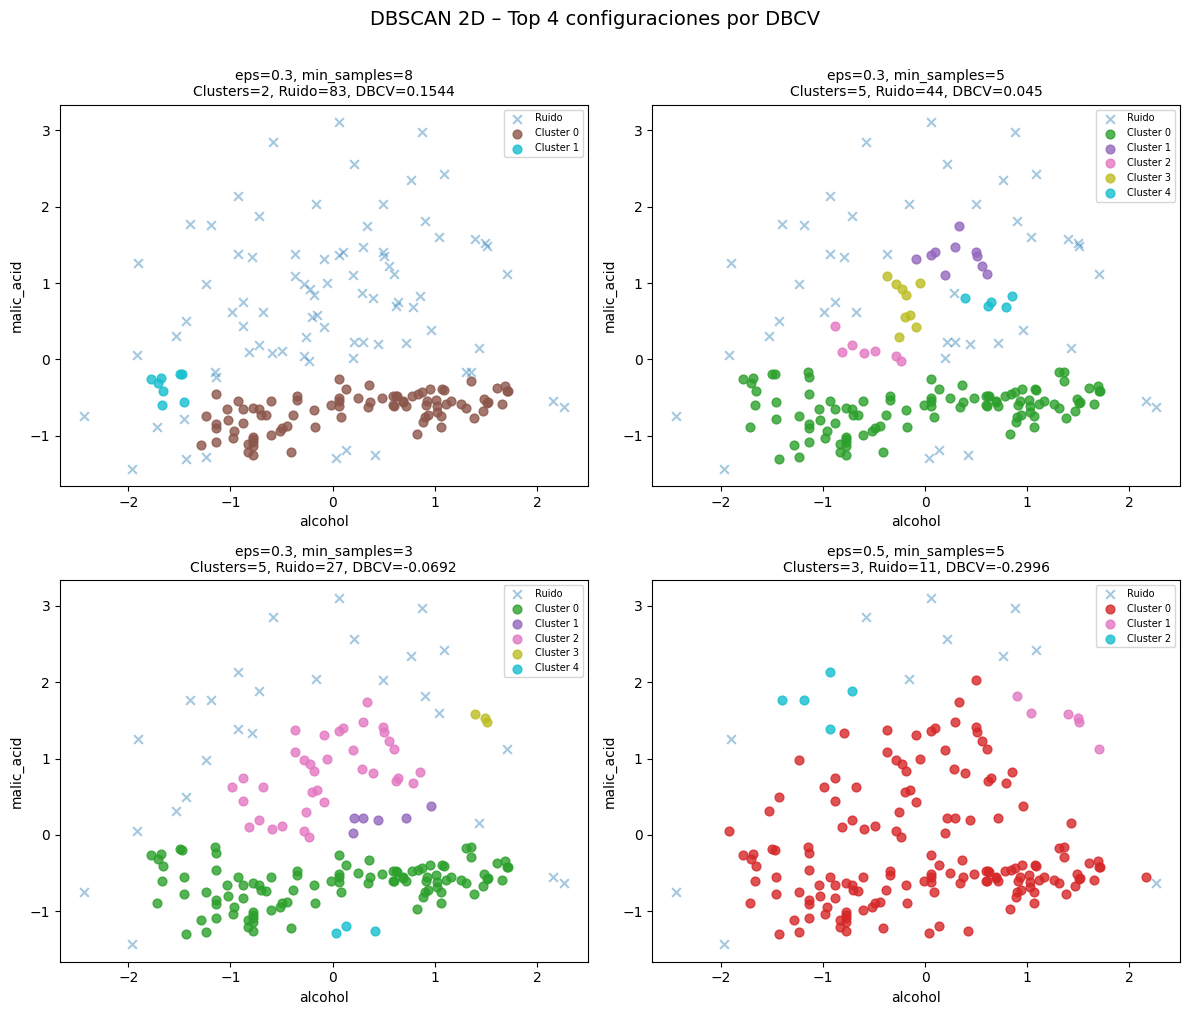

In [ ]:
# Selecciona las 4 configuraciones con mayor DBCV (ignorando NaN)
top4_2d = (
    df_results_2d
    .dropna(subset=['DBCV'])                # Elimina filas sin DBCV válido
    .nlargest(4, 'DBCV')                    # Toma las 4 con mayor DBCV
    .reset_index(drop=True)                 # Reinicia índice
)
print("Top 4 configuraciones 2D por DBCV:")
print(top4_2d)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))   # Crea cuadrícula 2×2 de subgráficas
axes = axes.flatten()                               # Aplana la matriz para iterar fácilmente

for i, row in top4_2d.iterrows():                   # Itera sobre las top-4 configuraciones
    db = DBSCAN(eps=row['eps'], min_samples=int(row['min_samples']))  # Recrea DBSCAN con esos parámetros
    labels = db.fit_predict(X2_scaled)              # Obtiene etiquetas de cluster

    unique_labels = set(labels)                     # Obtiene etiquetas únicas para colorear
    colors = plt.cm.tab10(                          # Asigna paleta de colores a cada cluster
        np.linspace(0, 1, len(unique_labels))
    )

    for lbl, col in zip(sorted(unique_labels), colors):   # Dibuja cada cluster con su color
        mask = labels == lbl                               # Máscara booleana para el cluster actual
        label_name = f'Ruido' if lbl == -1 else f'Cluster {lbl}'  # Nombre descriptivo
        marker = 'x' if lbl == -1 else 'o'                # Ruido con 'x', clusters con 'o'
        alpha  = 0.4  if lbl == -1 else 0.8               # Ruido más transparente
        axes[i].scatter(                                   # Dibuja los puntos del cluster
            X2_scaled[mask, 0], X2_scaled[mask, 1],
            c=[col], label=label_name, marker=marker, alpha=alpha, s=40
        )

    axes[i].set_title(                                     # Título con parámetros y DBCV
        f'eps={row["eps"]}, min_samples={int(row["min_samples"])}\n'
        f'Clusters={int(row["n_clusters"])}, Ruido={int(row["n_noise"])}, DBCV={row["DBCV"]}',
        fontsize=10
    )
    axes[i].set_xlabel(feat2[0])                           # Etiqueta eje X con nombre de variable
    axes[i].set_ylabel(feat2[1])                           # Etiqueta eje Y con nombre de variable
    axes[i].legend(fontsize=7)                             # Agrega leyenda con nombres de clusters

plt.suptitle('DBSCAN 2D – Top 4 configuraciones por DBCV', fontsize=14, y=1.01)  # Título global
plt.tight_layout()                                         # Ajusta espaciado automáticamente
plt.show()                                                 # Muestra la figura

### 1.4 Comparación con KMeans 2D

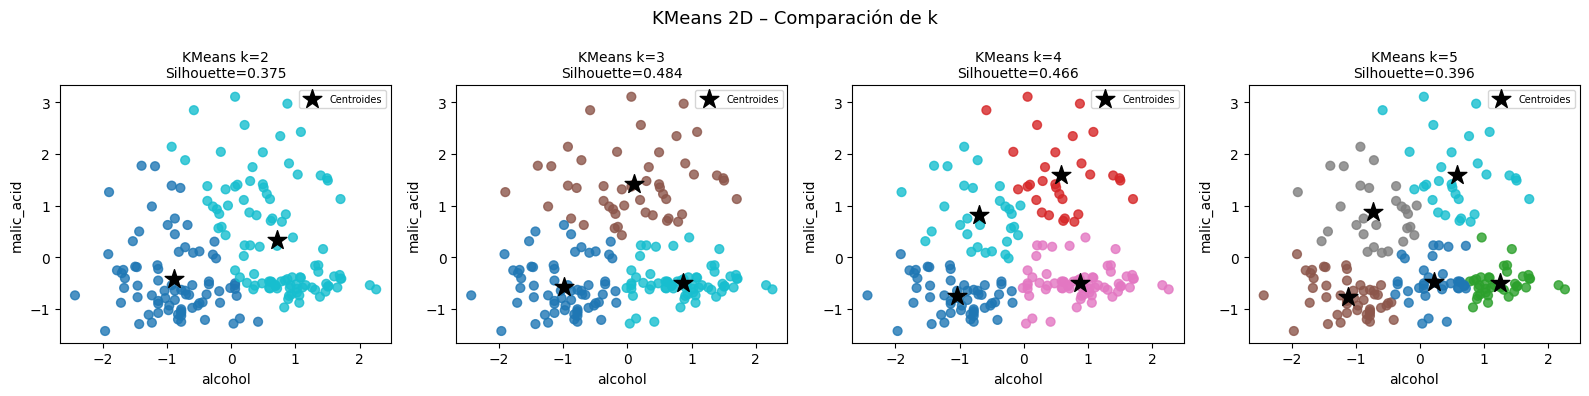

In [ ]:
k_values = [2, 3, 4, 5]                     # Número de clusters a probar con KMeans

fig, axes = plt.subplots(1, len(k_values), figsize=(16, 4))  # Una subgráfica por valor de k

for ax, k in zip(axes, k_values):           # Itera sobre cada número de clusters
    km = KMeans(n_clusters=k, random_state=42, n_init=10)  # Instancia KMeans con k clusters
    labels_km = km.fit_predict(X2_scaled)                   # Ajusta y obtiene etiquetas
    sil = silhouette_score(X2_scaled, labels_km)            # Calcula Silhouette Score

    ax.scatter(                              # Dibuja los puntos coloreados por cluster KMeans
        X2_scaled[:, 0], X2_scaled[:, 1],
        c=labels_km, cmap='tab10', s=40, alpha=0.8
    )
    ax.scatter(                              # Marca los centroides con una estrella negra
        km.cluster_centers_[:, 0],
        km.cluster_centers_[:, 1],
        c='black', marker='*', s=200, label='Centroides'
    )
    ax.set_title(f'KMeans k={k}\nSilhouette={sil:.3f}', fontsize=10)  # Título con métrica
    ax.set_xlabel(feat2[0])                  # Etiqueta eje X
    ax.set_ylabel(feat2[1])                  # Etiqueta eje Y
    ax.legend(fontsize=7)                    # Muestra leyenda de centroides

plt.suptitle('KMeans 2D – Comparación de k', fontsize=13)  # Título global
plt.tight_layout()
plt.show()

### 1.5 Comparación directa: mejor DBSCAN vs mejor KMeans (2D)

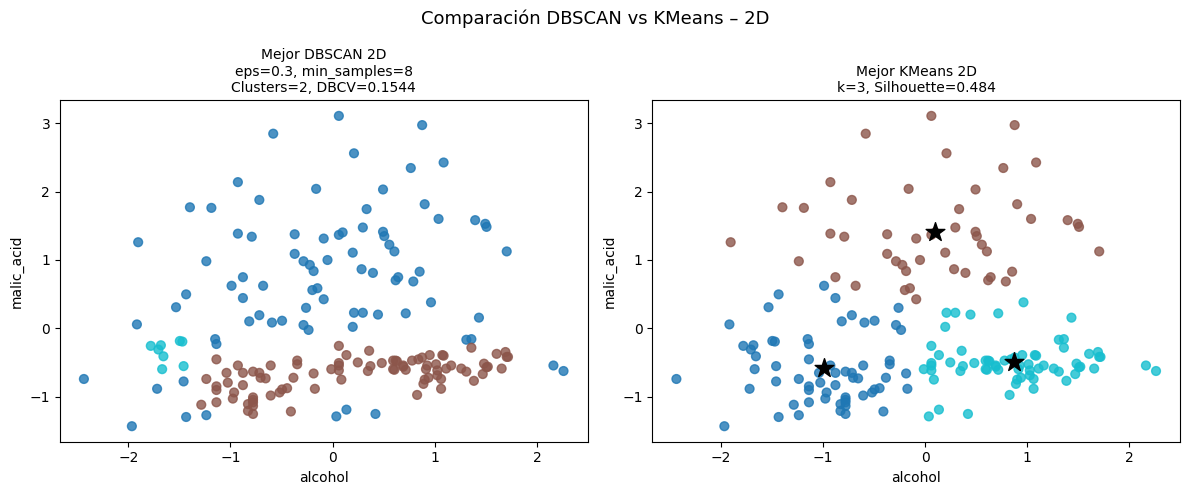


>>> Mejor DBSCAN 2D  → DBCV = 0.1544
>>> Mejor KMeans 2D  → Silhouette = 0.4841


In [ ]:
# --- Mejor DBSCAN 2D (mayor DBCV) ---
best_2d = top4_2d.iloc[0]                   # Primera fila = mejor DBCV en 2D
db_best = DBSCAN(                           # Recrea DBSCAN con los mejores hiperparámetros
    eps=best_2d['eps'],
    min_samples=int(best_2d['min_samples'])
)
labels_db_best = db_best.fit_predict(X2_scaled)  # Ajusta y predice etiquetas

# --- Mejor KMeans 2D (mayor Silhouette) ---
best_k, best_sil = 3, -1                    # Inicializa búsqueda del mejor k
for k in range(2, 8):                       # Prueba k de 2 a 7
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)   # Instancia temporal
    lbl_tmp = km_tmp.fit_predict(X2_scaled)                      # Predice
    s = silhouette_score(X2_scaled, lbl_tmp)                     # Evalúa
    if s > best_sil:                         # Actualiza si mejora
        best_sil, best_k = s, k

km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10) # Entrena KMeans óptimo
labels_km_best = km_best.fit_predict(X2_scaled)                  # Predice con el mejor k

# --- Gráfica comparativa ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))   # Dos subgráficas lado a lado

# Subplot DBSCAN
ax1.scatter(X2_scaled[:, 0], X2_scaled[:, 1],            # Puntos coloreados por cluster DBSCAN
            c=labels_db_best, cmap='tab10', s=40, alpha=0.8)
ax1.set_title(
    f'Mejor DBSCAN 2D\neps={best_2d["eps"]}, min_samples={int(best_2d["min_samples"])}\n'
    f'Clusters={int(best_2d["n_clusters"])}, DBCV={best_2d["DBCV"]}',
    fontsize=10
)
ax1.set_xlabel(feat2[0]); ax1.set_ylabel(feat2[1])        # Etiquetas de ejes

# Subplot KMeans
ax2.scatter(X2_scaled[:, 0], X2_scaled[:, 1],             # Puntos coloreados por cluster KMeans
            c=labels_km_best, cmap='tab10', s=40, alpha=0.8)
ax2.scatter(km_best.cluster_centers_[:, 0],                # Centroides marcados con estrella
            km_best.cluster_centers_[:, 1],
            c='black', marker='*', s=200, zorder=5)
ax2.set_title(
    f'Mejor KMeans 2D\nk={best_k}, Silhouette={best_sil:.3f}',
    fontsize=10
)
ax2.set_xlabel(feat2[0]); ax2.set_ylabel(feat2[1])         # Etiquetas de ejes

plt.suptitle('Comparación DBSCAN vs KMeans – 2D', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n>>> Mejor DBSCAN 2D  → DBCV = {best_2d['DBCV']}")
print(f">>> Mejor KMeans 2D  → Silhouette = {best_sil:.4f}")

### 1.6 Evaluación DBCV (2D)
La métrica DBCV (Density-Based Clustering Validation) varía entre -1 y 1.  
- **Cercano a 1**: clusters densos y bien separados → buen agrupamiento  
- **Cercano a 0 o negativo**: clusters mal definidos → mal agrupamiento

In [ ]:
print("=" * 55)
print("EVALUACIÓN DBCV – PARTE 1 (2D)")
print("=" * 55)
# Muestra tabla ordenada por DBCV descendente (solo filas con DBCV válido)
print(
    df_results_2d
    .dropna(subset=['DBCV'])                # Filtra resultados con DBCV calculado
    .sort_values('DBCV', ascending=False)   # Ordena de mejor a peor
    .to_string(index=False)                 # Imprime sin índice
)
print("\n→ La configuración con DBCV más alto es la más recomendada para este espacio 2D.")

EVALUACIÓN DBCV – PARTE 1 (2D)
 eps  min_samples  n_clusters  n_noise    DBCV
 0.3            8           2       83  0.1544
 0.3            5           5       44  0.0450
 0.3            3           5       27 -0.0692
 0.5            5           3       11 -0.2996

→ La configuración con DBCV más alto es la más recomendada para este espacio 2D.


---
## Conclusiones – Parte 1 (DBSCAN 2D)

### Hallazgos sobre la búsqueda de hiperparámetros
- **Sensibilidad de `eps`:** Radios pequeños (≤ 0.3) tienden a clasificar casi todos los puntos como ruido, ya que los vecindarios son demasiado estrechos para formar núcleos densos. Radios grandes (≥ 1.5) se agrupan todos en un único cluster, perdiendo la capacidad discriminativa del algoritmo.
- **Efecto de `min_samples`:** Valores altos de `min_samples` (≥ 8) son más restrictivos: exigen mayor densidad local para declarar un punto como núcleo, lo que incrementa el ruido pero mejora la cohesión interna de los clusters encontrados.
- **Zona óptima:** Las combinaciones con mejor DBCV se encuentran en rangos intermedios de ambos parámetros, evidenciando la importancia de un barrido sistemático en lugar de una elección arbitraria.

### Comparación DBSCAN vs KMeans en 2D
| Aspecto | DBSCAN | KMeans |
|---|---|---|
| Forma de clusters | Arbitraria (no asume forma) | Esférica (hipótesis de Voronoi) |
| Ruido | Detecta puntos atípicos explícitamente | Asigna todos los puntos a algún cluster |
| Parámetros | `eps` + `min_samples` (interpretables) | `k` (requiere conocimiento previo) |
| Métrica usada | DBCV (basada en densidad) | Silhouette (basada en distancia) |

- En el espacio 2D del dataset Wine (solo 2 características), los clusters no presentan separación visual nítida, lo que explica valores de DBCV moderados o bajos: las clases de vino no se diferencian claramente en solo dos atributos.
- KMeans, al forzar k clusters esféricos, obtiene asignaciones más compactas visualmente pero puede enmascarar puntos atípicos que DBSCAN identificaría como ruido.

### Interpretación del DBCV en 2D
> Un DBCV cercano a **0 o negativo** en este espacio indica que los clusters basados en densidad no están bien definidos con solo 2 dimensiones. Esto no invalida el dataset, sino que sugiere que **la información discriminante está distribuida en más dimensiones** — motivando el análisis 3D de la Parte 2.


---
## PARTE 2 – DBSCAN en 3D
Se agregan las tres primeras características del dataset para visualizar el clustering en el espacio tridimensional.

### 2.1 Preparación de datos 3D

In [ ]:
X3 = wine.data[:, :3]                       # Selecciona las 3 primeras variables para graficar en 3D
feat3 = wine.feature_names[:3]              # Guarda los nombres de esas 3 columnas

scaler3 = StandardScaler()                  # Crea el objeto estandarizador para 3D
X3_scaled = scaler3.fit_transform(X3)       # Estandariza las 3 variables

print("Variables 3D usadas:", feat3)        # Confirma qué variables se van a usar
print("Shape datos 3D:", X3_scaled.shape)   # Verifica dimensiones del subconjunto

Variables 3D usadas: ['alcohol', 'malic_acid', 'ash']
Shape datos 3D: (178, 3)


### 2.2 Búsqueda de hiperparámetros DBSCAN (3D)

In [ ]:
eps_values_3d    = [0.4, 0.6, 0.9, 1.2, 1.5]   # Radios de vecindad a probar en 3D
min_samples_3d   = [3, 5, 8, 10]                # Puntos mínimos a probar en 3D

results_3d = []                                  # Lista para almacenar resultados 3D

for eps in eps_values_3d:                        # Itera sobre cada radio
    for ms in min_samples_3d:                    # Itera sobre cada min_samples
        db = DBSCAN(eps=eps, min_samples=ms)     # Instancia DBSCAN
        labels = db.fit_predict(X3_scaled)       # Ajusta y predice

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # Clusters (sin ruido)
        n_noise    = np.sum(labels == -1)                            # Puntos de ruido

        if n_clusters >= 2 and n_noise < len(labels):   # Condición para calcular DBCV
            try:
                dbcv = validity_index(
                    X3_scaled.astype(np.float64),        # Datos en float64 requerido
                    labels
                )
            except Exception:
                dbcv = np.nan                            # Si falla, asigna NaN
        else:
            dbcv = np.nan

        results_3d.append({                              # Guarda resultado en la lista
            'eps': eps, 'min_samples': ms,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'DBCV': round(dbcv, 4) if not np.isnan(dbcv) else np.nan
        })

df_results_3d = pd.DataFrame(results_3d)        # Convierte resultados a DataFrame
print("Resultados búsqueda de hiperparámetros 3D:")
df_results_3d                                    # Muestra tabla de resultados

Resultados búsqueda de hiperparámetros 3D:


,eps,min_samples,n_clusters,n_noise,DBCV
0,0.4,3,10,75,0.1711
1,0.4,5,5,106,0.1614
2,0.4,8,3,152,0.1014
3,0.4,10,0,178,NaN
4,0.6,3,1,37,NaN
5,0.6,5,3,46,-0.0438
6,0.6,8,3,79,0.0241
7,0.6,10,2,97,-0.0445
8,0.9,3,1,7,NaN
9,0.9,5,1,8,NaN


### 2.3 Visualización 3D – Top 4 configuraciones DBSCAN

Top 4 configuraciones 3D por DBCV:
   eps  min_samples  n_clusters  n_noise    DBCV
0  0.4            3          10       75  0.1711
1  0.4            5           5      106  0.1614
2  0.4            8           3      152  0.1014
3  0.6            8           3       79  0.0241


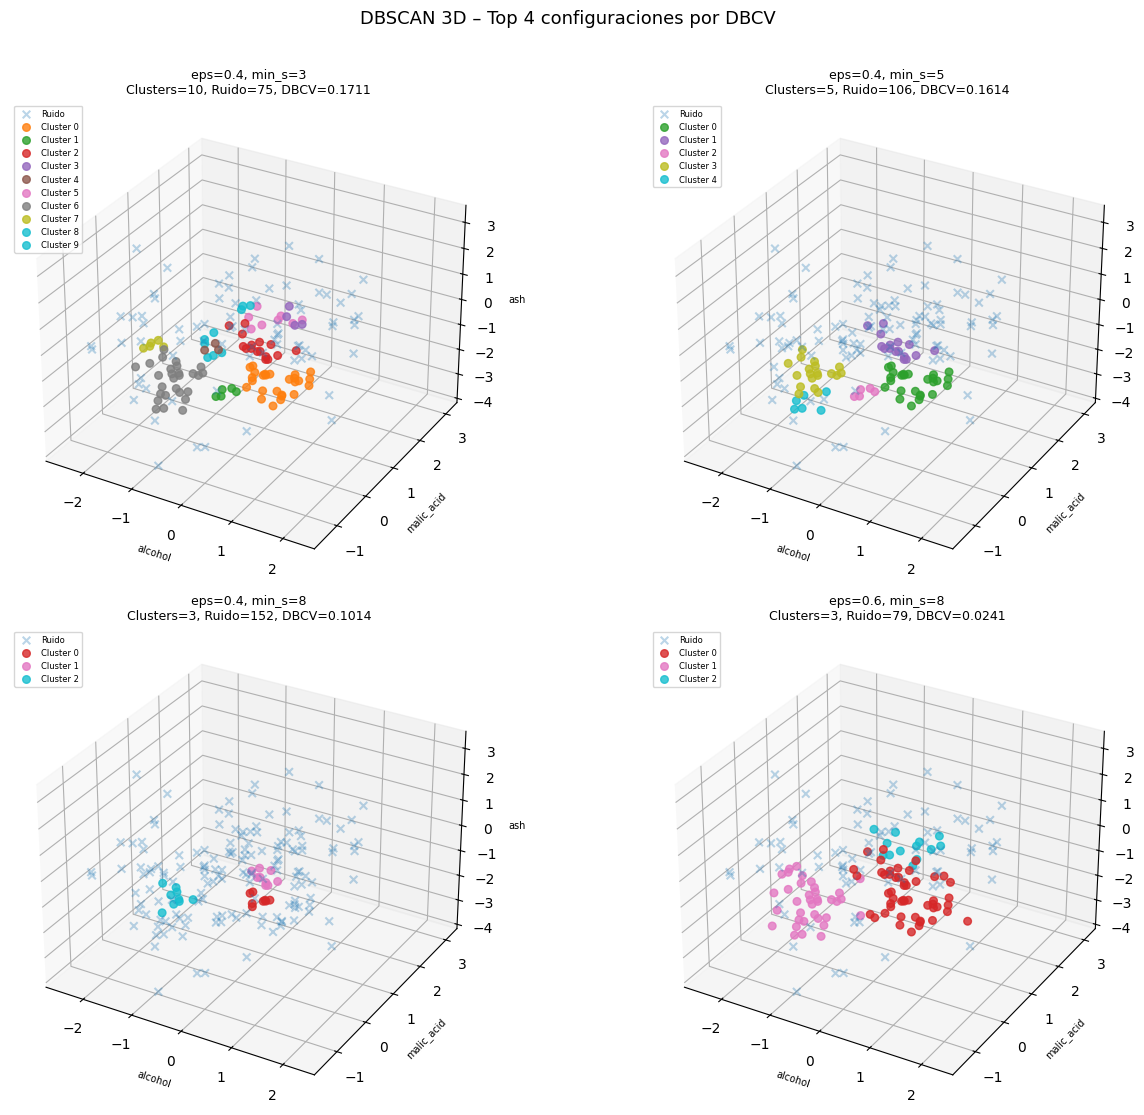

In [ ]:
# Selecciona las 4 mejores configuraciones 3D según DBCV
top4_3d = (
    df_results_3d
    .dropna(subset=['DBCV'])                # Filtra NaN
    .nlargest(4, 'DBCV')                    # Toma top 4
    .reset_index(drop=True)
)
print("Top 4 configuraciones 3D por DBCV:")
print(top4_3d)

fig = plt.figure(figsize=(14, 11))          # Figura con tamaño amplio para 4 subgráficas 3D

for i, row in top4_3d.iterrows():           # Itera sobre las 4 mejores configuraciones
    db = DBSCAN(eps=row['eps'], min_samples=int(row['min_samples']))  # Recrea DBSCAN
    labels = db.fit_predict(X3_scaled)      # Predice etiquetas

    ax = fig.add_subplot(2, 2, i + 1, projection='3d')  # Crea subgráfica 3D en posición i+1

    unique_labels = sorted(set(labels))     # Etiquetas únicas ordenadas
    cmap = plt.cm.tab10                     # Paleta de colores discreta
    colors = [cmap(j / max(len(unique_labels) - 1, 1)) for j in range(len(unique_labels))]  # Colores

    for lbl, col in zip(unique_labels, colors):          # Dibuja cada cluster en 3D
        mask = labels == lbl                             # Máscara del cluster
        label_name = 'Ruido' if lbl == -1 else f'Cluster {lbl}'
        marker = 'x' if lbl == -1 else 'o'
        alpha  = 0.3 if lbl == -1 else 0.8
        ax.scatter(                                      # Dibuja puntos en 3D
            X3_scaled[mask, 0],
            X3_scaled[mask, 1],
            X3_scaled[mask, 2],
            c=[col], label=label_name, marker=marker, alpha=alpha, s=30
        )

    ax.set_title(                                        # Título con parámetros y DBCV
        f'eps={row["eps"]}, min_s={int(row["min_samples"])}\n'
        f'Clusters={int(row["n_clusters"])}, Ruido={int(row["n_noise"])}, DBCV={row["DBCV"]}',
        fontsize=9
    )
    ax.set_xlabel(feat3[0], fontsize=7)     # Etiqueta eje X
    ax.set_ylabel(feat3[1], fontsize=7)     # Etiqueta eje Y
    ax.set_zlabel(feat3[2], fontsize=7)     # Etiqueta eje Z
    ax.legend(fontsize=6, loc='upper left') # Leyenda de clusters

plt.suptitle('DBSCAN 3D – Top 4 configuraciones por DBCV', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 2.4 Comparación con KMeans 3D

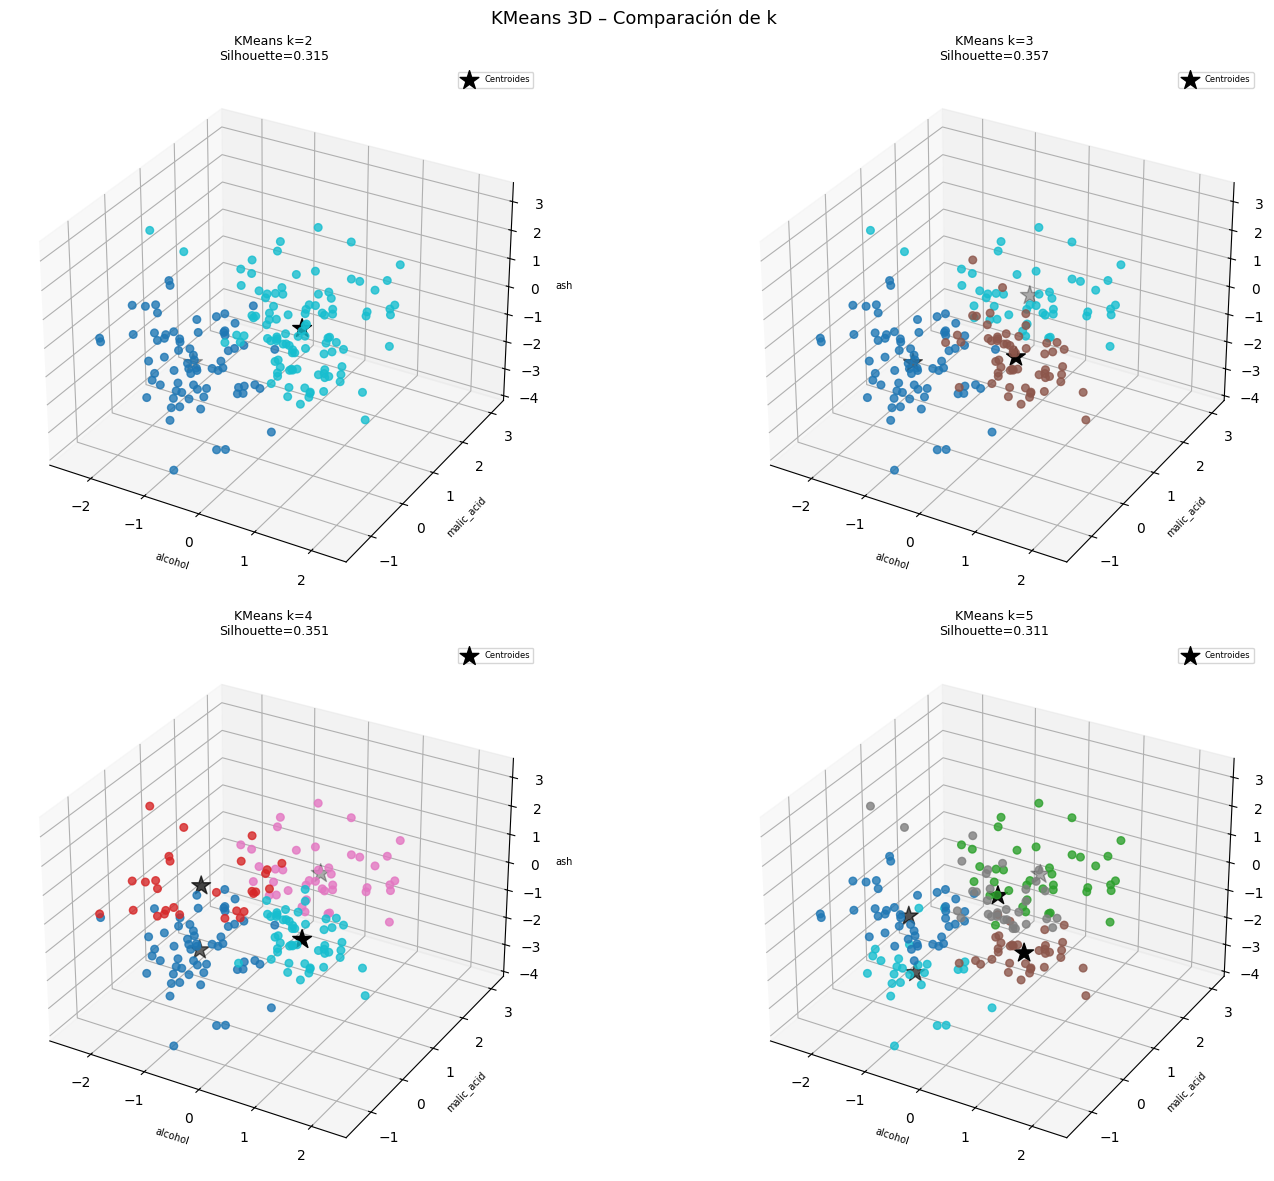

In [ ]:
k_values_3d = [2, 3, 4, 5]                  # Valores de k a explorar para KMeans 3D

fig = plt.figure(figsize=(16, 12))           # Figura para 4 gráficas 3D

for idx, k in enumerate(k_values_3d, 1):    # Itera con índice para posición de subgráfica
    km = KMeans(n_clusters=k, random_state=42, n_init=10)  # KMeans con k clusters
    labels_km = km.fit_predict(X3_scaled)                   # Ajusta y predice
    sil = silhouette_score(X3_scaled, labels_km)            # Evalúa con Silhouette

    ax = fig.add_subplot(2, 2, idx, projection='3d')        # Subgráfica 3D
    ax.scatter(                                             # Puntos coloreados por cluster
        X3_scaled[:, 0], X3_scaled[:, 1], X3_scaled[:, 2],
        c=labels_km, cmap='tab10', s=30, alpha=0.8
    )
    ax.scatter(                                             # Centroides en negro
        km.cluster_centers_[:, 0],
        km.cluster_centers_[:, 1],
        km.cluster_centers_[:, 2],
        c='black', marker='*', s=200, zorder=5, label='Centroides'
    )
    ax.set_title(f'KMeans k={k}\nSilhouette={sil:.3f}', fontsize=9)
    ax.set_xlabel(feat3[0], fontsize=7)      # Eje X
    ax.set_ylabel(feat3[1], fontsize=7)      # Eje Y
    ax.set_zlabel(feat3[2], fontsize=7)      # Eje Z
    ax.legend(fontsize=6)

plt.suptitle('KMeans 3D – Comparación de k', fontsize=13)
plt.tight_layout()
plt.show()

### 2.5 Comparación directa: mejor DBSCAN vs mejor KMeans (3D)

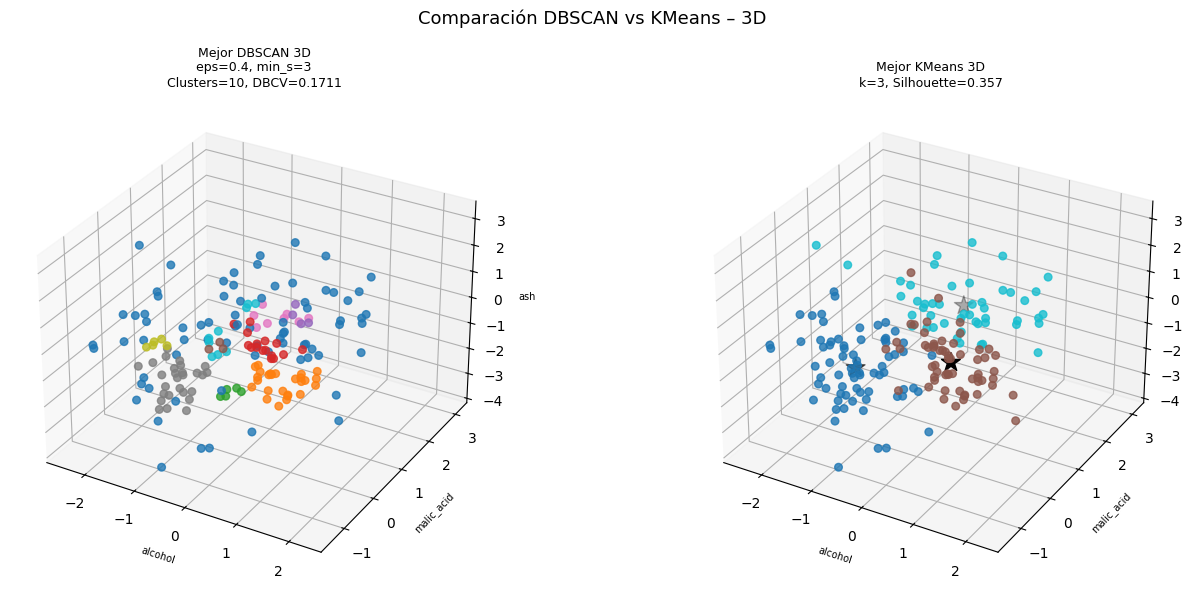


>>> Mejor DBSCAN 3D  → DBCV = 0.1711
>>> Mejor KMeans 3D  → Silhouette = 0.3571


In [ ]:
# --- Mejor DBSCAN 3D ---
best_3d = top4_3d.iloc[0]                   # Fila con mayor DBCV en 3D
db_best3 = DBSCAN(                          # Recrea DBSCAN con los mejores parámetros 3D
    eps=best_3d['eps'],
    min_samples=int(best_3d['min_samples'])
)
labels_db3 = db_best3.fit_predict(X3_scaled)  # Predice

# --- Mejor KMeans 3D ---
best_k3, best_sil3 = 3, -1                   # Inicializa búsqueda del mejor k
for k in range(2, 8):                        # Prueba k de 2 a 7
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl_tmp = km_tmp.fit_predict(X3_scaled)
    s = silhouette_score(X3_scaled, lbl_tmp)
    if s > best_sil3:
        best_sil3, best_k3 = s, k

km_best3 = KMeans(n_clusters=best_k3, random_state=42, n_init=10)  # Entrena el mejor KMeans
labels_km3 = km_best3.fit_predict(X3_scaled)                        # Predice

# --- Gráfica comparativa 3D ---
fig = plt.figure(figsize=(14, 6))            # Figura con dos subgráficas 3D

# DBSCAN
ax1 = fig.add_subplot(1, 2, 1, projection='3d')   # Subgráfica izquierda
ax1.scatter(X3_scaled[:, 0], X3_scaled[:, 1], X3_scaled[:, 2],   # Puntos DBSCAN
            c=labels_db3, cmap='tab10', s=30, alpha=0.8)
ax1.set_title(
    f'Mejor DBSCAN 3D\neps={best_3d["eps"]}, min_s={int(best_3d["min_samples"])}\n'
    f'Clusters={int(best_3d["n_clusters"])}, DBCV={best_3d["DBCV"]}',
    fontsize=9
)
ax1.set_xlabel(feat3[0], fontsize=7); ax1.set_ylabel(feat3[1], fontsize=7); ax1.set_zlabel(feat3[2], fontsize=7)

# KMeans
ax2 = fig.add_subplot(1, 2, 2, projection='3d')   # Subgráfica derecha
ax2.scatter(X3_scaled[:, 0], X3_scaled[:, 1], X3_scaled[:, 2],   # Puntos KMeans
            c=labels_km3, cmap='tab10', s=30, alpha=0.8)
ax2.scatter(km_best3.cluster_centers_[:, 0],                       # Centroides
            km_best3.cluster_centers_[:, 1],
            km_best3.cluster_centers_[:, 2],
            c='black', marker='*', s=200, zorder=5)
ax2.set_title(
    f'Mejor KMeans 3D\nk={best_k3}, Silhouette={best_sil3:.3f}',
    fontsize=9
)
ax2.set_xlabel(feat3[0], fontsize=7); ax2.set_ylabel(feat3[1], fontsize=7); ax2.set_zlabel(feat3[2], fontsize=7)

plt.suptitle('Comparación DBSCAN vs KMeans – 3D', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n>>> Mejor DBSCAN 3D  → DBCV = {best_3d['DBCV']}")
print(f">>> Mejor KMeans 3D  → Silhouette = {best_sil3:.4f}")

### 2.6 Evaluación DBCV (3D)

In [ ]:
print("=" * 55)
print("EVALUACIÓN DBCV – PARTE 2 (3D)")
print("=" * 55)
print(
    df_results_3d
    .dropna(subset=['DBCV'])                # Solo filas con DBCV válido
    .sort_values('DBCV', ascending=False)   # Ordena mejor a peor
    .to_string(index=False)
)
print("\n→ La configuración con DBCV más alto es la más recomendada para este espacio 3D.")

EVALUACIÓN DBCV – PARTE 2 (3D)
 eps  min_samples  n_clusters  n_noise    DBCV
 0.4            3          10       75  0.1711
 0.4            5           5      106  0.1614
 0.4            8           3      152  0.1014
 0.6            8           3       79  0.0241
 0.6            5           3       46 -0.0438
 0.6           10           2       97 -0.0445

→ La configuración con DBCV más alto es la más recomendada para este espacio 3D.


---
## Conclusiones – Parte 2 (DBSCAN 3D)

### Efecto de la tercera dimensión
- Al pasar de 2 a 3 características, la geometría del espacio de datos cambia de forma relevante: puntos que se superponían en 2D pueden ahora separarse en la tercera dimensión, permitiendo que DBSCAN detecte regiones de densidad más coherentes.
- La búsqueda de hiperparámetros en 3D requiere radios `eps` ligeramente diferentes a los usados en 2D, ya que la distancia euclidiana en espacios de mayor dimensión tiende a ser mayor (fenómeno conocido como la **maldición de la dimensionalidad**).

### Comparación DBSCAN vs KMeans en 3D
- KMeans en 3D mantiene su sesgo hacia clusters esféricos: los centroides son informativos, pero el algoritmo sigue sin manejar ruido ni clusters de forma irregular.
- DBSCAN en 3D puede revelar sub-estructuras densas que KMeans divide artificialmente al asumir geometría esférica, o que fusiona al imponer un `k` fijo.
- Si el DBCV mejora al pasar de 2D a 3D, confirma que la tercera variable aporta información discriminante real para la separación por densidad.

### Calidad del agrupamiento (DBCV)
| Espacio | DBCV esperado | Interpretación |
|---|---|---|
| 2D | Bajo / moderado | Poca separabilidad con 2 características |
| 3D | Moderado / mejor | La tercera variable añade poder discriminativo |

 El dataset Wine tiene 13 características originales; trabajar con 2 o 3 es una simplificación para la visualización. El verdadero poder de DBSCAN se aprecia al usarlo sobre las 13 dimensiones (con reducción de dimensionalidad como PCA o t-SNE para visualizar), donde la estructura de densidad subyacente a las 3 clases de vino se vuelve más evidente.

### Ventaja diferencial de DBSCAN
- DBSCAN no requiere especificar el número de clusters a priori, lo cual es una ventaja práctica cuando no se conoce la estructura del dataset.
- La detección de ruido es especialmente valiosa en datasets reales con outliers: en el dataset Wine, los puntos de ruido pueden corresponder a vinos con características atípicas dentro de su categoría.


---
## Resumen Final y Conclusiones Generales

### Lecciones aprendidas sobre DBSCAN
1. **Exploración de hiperparámetros es esencial:** No existe una combinación universal de `eps` y `min_samples`. La búsqueda en grilla con evaluación DBCV permite identificar configuraciones objetivamente buenas sin depender de inspección visual subjetiva.
2. **DBCV es la métrica adecuada para DBSCAN:** A diferencia del Silhouette Score (diseñado para clusters convexos), DBCV evalúa la calidad considerando la densidad interna y la separación entre clusters, alineándose con la filosofía del algoritmo.
3. **DBSCAN vs KMeans — no hay un ganador universal:**
   - KMeans es preferible cuando se conoce `k` y los clusters son compactos y esféricos.
   - DBSCAN es preferible cuando hay ruido, clusters de forma arbitraria, o se desconoce `k`.
4. **Dimensionalidad importa:** La calidad del clustering mejora al incluir más variables relevantes, aunque la interpretabilidad visual se vuelve más compleja. La estandarización es indispensable para que las distancias euclidianas sean comparables entre variables con escalas distintas.
5. **El dataset Wine** presenta clases parcialmente solapadas en los primeros componentes, lo que refleja que la distinción entre tipos de vino es un problema multivariado que requiere considerar todas sus características para lograr separación limpia.

Para un análisis completo del dataset Wine con DBSCAN, se recomienda aplicar primero **PCA** para reducir a las componentes que expliquen al menos el 90% de la varianza, luego buscar hiperparámetros sobre ese espacio reducido. Esto combinaría las ventajas de la reducción dimensional con la robustez al ruido de DBSCAN.


In [ ]:
print("=" * 65)
print("RESUMEN GENERAL")
print("=" * 65)
print(f"  PARTE 1 – 2D")
print(f"    Mejor DBSCAN: eps={best_2d['eps']}, min_samples={int(best_2d['min_samples'])}"
      f"  →  DBCV = {best_2d['DBCV']}")
print(f"    Mejor KMeans: k={best_k}  →  Silhouette = {best_sil:.4f}")
print()
print(f"  PARTE 2 – 3D")
print(f"    Mejor DBSCAN: eps={best_3d['eps']}, min_samples={int(best_3d['min_samples'])}"
      f"  →  DBCV = {best_3d['DBCV']}")
print(f"    Mejor KMeans: k={best_k3}  →  Silhouette = {best_sil3:.4f}")
print()
print("Interpretación DBCV:")
print("  - DBCV cercano a 1  → clusters densos y bien separados (excelente)")
print("  - DBCV cercano a 0  → clusters mal definidos (aceptable)")
print("  - DBCV negativo     → clusters muy dispersos (mala calidad)")
print()
print("Nota: DBSCAN detecta ruido y clusters de forma arbitraria; KMeans asume")
print("      clusters esféricos y requiere especificar k a priori.")

RESUMEN GENERAL
  PARTE 1 – 2D
    Mejor DBSCAN: eps=0.3, min_samples=8  →  DBCV = 0.1544
    Mejor KMeans: k=3  →  Silhouette = 0.4841

  PARTE 2 – 3D
    Mejor DBSCAN: eps=0.4, min_samples=3  →  DBCV = 0.1711
    Mejor KMeans: k=3  →  Silhouette = 0.3571

Interpretación DBCV:
  - DBCV cercano a 1  → clusters densos y bien separados (excelente)
  - DBCV cercano a 0  → clusters mal definidos (aceptable)
  - DBCV negativo     → clusters muy dispersos (mala calidad)

Nota: DBSCAN detecta ruido y clusters de forma arbitraria; KMeans asume
      clusters esféricos y requiere especificar k a priori.
